In [1]:
# Importing all necessary libraries

import os
import cv2
import glob
import PIL
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from skimage import data
from skimage.util import montage 
import skimage.transform as skTrans
from skimage.transform import rotate
from skimage.transform import resize
from PIL import Image, ImageOps  


# neural imaging
import nilearn as nl
import nibabel as nib
import nilearn.plotting as nlplt
# !pip install git+https://github.com/miykael/gif_your_nifti # nifti to gif 
# import gif_your_nifti.core as gif2nif


# ml libs
import keras
import keras.backend as K
from keras.callbacks import CSVLogger
from keras.layers import Flatten
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, TensorBoard
#from tensorflow.keras.layers.experimental import preprocessing

# Make numpy printouts easier to read.
np.set_printoptions(precision=3, suppress=True)

In [2]:
# DEFINE seg-areas  
SEGMENT_CLASSES = {
    0 : 'NOT tumor',
    1 : 'NECROTIC/CORE', # or NON-ENHANCING tumor CORE
    2 : 'EDEMA',
    3 : 'ENHANCING' # original 4 -> converted into 3 later
}

# there are 155 slices per volume
# to start at 5 and use 145 slices means we will skip the first 5 and last 5 
VOLUME_SLICES = 155
VOLUME_START_AT = 0 #22 # first slice of volume that we will include
IMG_SIZE=128

TRAIN_DATASET_PATH = os.path.join(os.getcwd(), 'BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/')
VALIDATION_DATASET_PATH = os.path.join(os.getcwd(), 'BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/')

# Neural Network Tumor Segmentation Classifier Starts Here 

## Base model from Kaggle see https://www.kaggle.com/code/rastislav/3d-mri-brain-tumor-segmentation-u-net made by Ratislav Kopál
## (Adjusted to required specification)

In [3]:
# dice loss as defined above for 4 classes
def dice_coef(y_true, y_pred, smooth=1.0):
    class_num = 4
    for i in range(class_num):
        y_true_f = K.flatten(y_true[:,:,:,i])
        y_pred_f = K.flatten(y_pred[:,:,:,i])
        intersection = K.sum(y_true_f * y_pred_f)
        loss = ((2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth))
   #     K.print_tensor(loss, message='loss value for class {} : '.format(SEGMENT_CLASSES[i]))
        if i == 0:
            total_loss = loss
        else:
            total_loss = total_loss + loss
    total_loss = total_loss / class_num
#    K.print_tensor(total_loss, message=' total dice coef: ')
    return total_loss


 
# define per class evaluation of dice coef
# inspired by https://github.com/keras-team/keras/issues/9395
def dice_coef_necrotic(y_true, y_pred, epsilon=1e-6):
    intersection = K.sum(K.abs(y_true[:,:,:,1] * y_pred[:,:,:,1]))
    return (2. * intersection) / (K.sum(K.square(y_true[:,:,:,1])) + K.sum(K.square(y_pred[:,:,:,1])) + epsilon)

def dice_coef_edema(y_true, y_pred, epsilon=1e-6):
    intersection = K.sum(K.abs(y_true[:,:,:,2] * y_pred[:,:,:,2]))
    return (2. * intersection) / (K.sum(K.square(y_true[:,:,:,2])) + K.sum(K.square(y_pred[:,:,:,2])) + epsilon)

def dice_coef_enhancing(y_true, y_pred, epsilon=1e-6):
    intersection = K.sum(K.abs(y_true[:,:,:,3] * y_pred[:,:,:,3]))
    return (2. * intersection) / (K.sum(K.square(y_true[:,:,:,3])) + K.sum(K.square(y_pred[:,:,:,3])) + epsilon)

# Computing Precision 
def precision(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = true_positives / (predicted_positives + K.epsilon())
        return precision
    
# Computing Sensitivity      
def sensitivity(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    return true_positives / (possible_positives + K.epsilon())

# Computing Specificity
def specificity(y_true, y_pred):
    true_negatives = K.sum(K.round(K.clip((1-y_true) * (1-y_pred), 0, 1)))
    possible_negatives = K.sum(K.round(K.clip(1-y_true, 0, 1)))
    return true_negatives / (possible_negatives + K.epsilon())

In [4]:
# source https://naomi-fridman.medium.com/multi-class-image-segmentation-a5cc671e647a

def build_unet(inputs, ker_init, dropout):
    conv1 = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(inputs)
    conv1 = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv1)
    
    pool = MaxPooling2D(pool_size=(2, 2))(conv1)
    conv = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool)
    conv = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv)
    
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv)
    conv2 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool1)
    conv2 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv2)
    
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    conv3 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool2)
    conv3 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv3)
    
    
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv3)
    conv5 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool4)
    conv5 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv5)
    drop5 = Dropout(dropout)(conv5)

    up7 = Conv2D(256, 2, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(UpSampling2D(size = (2,2))(drop5))
    merge7 = concatenate([conv3,up7], axis = 3)
    conv7 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(merge7)
    conv7 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv7)

    up8 = Conv2D(128, 2, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(UpSampling2D(size = (2,2))(conv7))
    merge8 = concatenate([conv2,up8], axis = 3)
    conv8 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(merge8)
    conv8 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv8)

    up9 = Conv2D(64, 2, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(UpSampling2D(size = (2,2))(conv8))
    merge9 = concatenate([conv,up9], axis = 3)
    conv9 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(merge9)
    conv9 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv9)
    
    up = Conv2D(32, 2, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(UpSampling2D(size = (2,2))(conv9))
    merge = concatenate([conv1,up], axis = 3)
    conv = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(merge)
    conv = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv)
    
    conv10 = Conv2D(4, (1,1), activation = 'softmax')(conv)
    
    return Model(inputs = inputs, outputs = conv10)

input_layer = Input((IMG_SIZE, IMG_SIZE, 2))

model = build_unet(input_layer, 'he_normal', 0.2)
model.compile(loss="categorical_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=0.001), metrics = ['accuracy',tf.keras.metrics.MeanIoU(num_classes=4), dice_coef, precision, sensitivity, specificity, dice_coef_necrotic, dice_coef_edema ,dice_coef_enhancing] )

In [5]:
# lists of directories with studies
train_and_val_directories = [f.path for f in os.scandir(TRAIN_DATASET_PATH) if f.is_dir()]

# file BraTS20_Training_355 has ill formatted name for for seg.nii file
train_and_val_directories.remove(TRAIN_DATASET_PATH+'BraTS20_Training_355')

def pathListIntoIds(dirList):
    x = []
    for i in range(0,len(dirList)):
        x.append(dirList[i][dirList[i].rfind('/')+1:])
    return x

train_and_test_ids = pathListIntoIds(train_and_val_directories); 

print(f'total number of pre-labeled MRI scans: {len(train_and_test_ids)}')
# Seperate data into 80% model build, 20% Validation
train_test_ids, val_ids = train_test_split(train_and_test_ids,test_size=0.2) 
# 50% of training data to train NN, 50% of training data to calibrate conformal framework, MUCH less is required for conformal framework to hold
model_ids, conformal_ids = train_test_split(train_test_ids,test_size=0.5)
# Split NN training date into 85% train, 15% test
train_ids, test_ids = train_test_split(model_ids,test_size=0.15) 

total number of pre-labeled MRI scans: 368


In [6]:
class DataGenerator(keras.utils.Sequence):
    'Generates data for Keras'
    def __init__(self, list_IDs, dim=(IMG_SIZE,IMG_SIZE), batch_size = 1, n_channels = 2, shuffle=True):
        'Initialization'
        self.dim = dim
        self.batch_size = batch_size
        self.list_IDs = list_IDs
        self.n_channels = n_channels
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        'Denotes the number of batches per epoch'
        return int(np.floor(len(self.list_IDs) / self.batch_size))

    def __getitem__(self, index):
        'Generate one batch of data'
        # Generate indexes of the batch
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]

        # Find list of IDs
        Batch_ids = [self.list_IDs[k] for k in indexes]

        # Generate data
        X, y = self.__data_generation(Batch_ids)

        return X, y

    def on_epoch_end(self):
        'Updates indexes after each epoch'
        self.indexes = np.arange(len(self.list_IDs))
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

    def __data_generation(self, Batch_ids):
        'Generates data containing batch_size samples' # X : (n_samples, *dim, n_channels)
        # Initialization
        X = np.zeros((self.batch_size*VOLUME_SLICES, *self.dim, self.n_channels))
        y = np.zeros((self.batch_size*VOLUME_SLICES, 240, 240))
        Y = np.zeros((self.batch_size*VOLUME_SLICES, *self.dim, 4))

        
        # Generate data
        for c, i in enumerate(Batch_ids):
            case_path = os.path.join(TRAIN_DATASET_PATH, i)

            data_path = os.path.join(case_path, f'{i}_flair.nii');
            flair = nib.load(data_path).get_fdata()    

            data_path = os.path.join(case_path, f'{i}_t1ce.nii');
            ce = nib.load(data_path).get_fdata()
            
            data_path = os.path.join(case_path, f'{i}_seg.nii');
            seg = nib.load(data_path).get_fdata()
        
            for j in range(VOLUME_SLICES):
                 X[j +VOLUME_SLICES*c,:,:,0] = cv2.resize(flair[:,:,j+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE));
                 X[j +VOLUME_SLICES*c,:,:,1] = cv2.resize(ce[:,:,j+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE));

                 y[j +VOLUME_SLICES*c] = seg[:,:,j+VOLUME_START_AT];
                    
        # Generate masks
        y[y==4] = 3;
        mask = tf.one_hot(y, 4);
        Y = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE));
        return X/np.max(X), Y
        
training_generator = DataGenerator(train_ids)
valid_generator = DataGenerator(val_ids)
test_generator = DataGenerator(test_ids)

### Import pretrained weights to save time, uncomment to self train

In [7]:
csv_logger = CSVLogger('training.log', separator=',', append=False)


callbacks = [
#     keras.callbacks.EarlyStopping(monitor='loss', min_delta=0,
#                               patience=2, verbose=1, mode='auto'),
      keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=2, min_lr=0.000001, verbose=1),
#  keras.callbacks.ModelCheckpoint(filepath = 'model_.{epoch:02d}-{val_loss:.6f}.m5',
#                             verbose=1, save_best_only=True, save_weights_only = True)
        csv_logger
    ]

In [8]:
K.clear_session()

# history =  model.fit(training_generator,
#                     epochs=35,
#                     steps_per_epoch=len(train_ids),
#                     callbacks= callbacks,
#                     validation_data = valid_generator
#                     )  
# model.save("model_x1_1.h5")

/opt/anaconda3/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:34: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


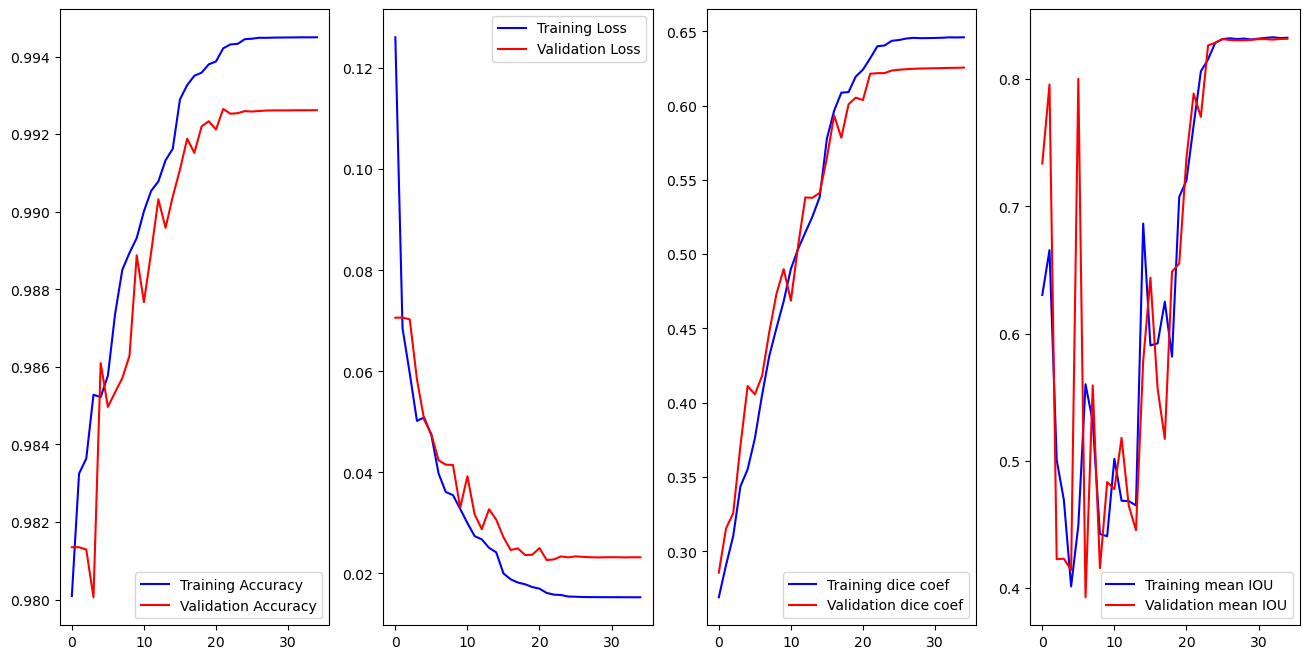

In [9]:
############ load trained model ################
model = keras.models.load_model(os.path.join(os.getcwd(), 'model_per_class.h5'), 
                                   custom_objects={ 'accuracy' : tf.keras.metrics.MeanIoU(num_classes=4),
                                                   "dice_coef": dice_coef,
                                                   "precision": precision,
                                                   "sensitivity":sensitivity,
                                                   "specificity":specificity,
                                                   "dice_coef_necrotic": dice_coef_necrotic,
                                                   "dice_coef_edema": dice_coef_edema,
                                                   "dice_coef_enhancing": dice_coef_enhancing
                                                  }, compile=False)

history = pd.read_csv(os.path.join(os.getcwd(), 'training_per_class.log'), sep=',', engine='python')

hist=history

############### ########## ####### #######

# hist=history.history

acc=hist['accuracy']
val_acc=hist['val_accuracy']

epoch=range(len(acc))

loss=hist['loss']
val_loss=hist['val_loss']

train_dice=hist['dice_coef']
val_dice=hist['val_dice_coef']

f,ax=plt.subplots(1,4,figsize=(16,8))

ax[0].plot(epoch,acc,'b',label='Training Accuracy')
ax[0].plot(epoch,val_acc,'r',label='Validation Accuracy')
ax[0].legend()

ax[1].plot(epoch,loss,'b',label='Training Loss')
ax[1].plot(epoch,val_loss,'r',label='Validation Loss')
ax[1].legend()

ax[2].plot(epoch,train_dice,'b',label='Training dice coef')
ax[2].plot(epoch,val_dice,'r',label='Validation dice coef')
ax[2].legend()

ax[3].plot(epoch,hist['mean_io_u'],'b',label='Training mean IOU')
ax[3].plot(epoch,hist['val_mean_io_u'],'r',label='Validation mean IOU')
ax[3].legend()

plt.show()

In [10]:
# mri type must one of 1) flair 2) t1 3) t1ce 4) t2 ------- or even 5) seg
# returns volume of specified study at `path`
def imageLoader(path):
    image = nib.load(path).get_fdata()
    X = np.zeros((self.batch_size*VOLUME_SLICES, *self.dim, self.n_channels))
    for j in range(VOLUME_SLICES):
        X[j +VOLUME_SLICES*c,:,:,0] = cv2.resize(image[:,:,j+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE));
        X[j +VOLUME_SLICES*c,:,:,1] = cv2.resize(ce[:,:,j+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE));

        y[j +VOLUME_SLICES*c] = seg[:,:,j+VOLUME_START_AT];
    return np.array(image)


# load nifti file at `path`
# and load each slice with mask from volume
# choose the mri type & resize to `IMG_SIZE`
def loadDataFromDir(path, list_of_files, mriType, n_images):
    scans = []
    masks = []
    for i in list_of_files[:n_images]:
        fullPath = glob.glob( i + '/*'+ mriType +'*')[0]
        currentScanVolume = imageLoader(fullPath)
        currentMaskVolume = imageLoader( glob.glob( i + '/*seg*')[0] ) 
        # for each slice in 3D volume, find also it's mask
        for j in range(0, currentScanVolume.shape[2]):
            scan_img = cv2.resize(currentScanVolume[:,:,j], dsize=(IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_AREA).astype('uint8')
            mask_img = cv2.resize(currentMaskVolume[:,:,j], dsize=(IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_AREA).astype('uint8')
            scans.append(scan_img[..., np.newaxis])
            masks.append(mask_img[..., np.newaxis])
    return np.array(scans, dtype='float32'), np.array(masks, dtype='float32')
        
#brains_list_test, masks_list_test = loadDataFromDir(VALIDATION_DATASET_PATH, test_directories, "flair", 5)

# Visualise Base Tumor Segmentation Classifier

In [11]:
def predictByPath(case_path, case):
    files = next(os.walk(case_path))[2]
    X = np.empty((VOLUME_SLICES, IMG_SIZE, IMG_SIZE, 2))
  #  y = np.empty((VOLUME_SLICES, IMG_SIZE, IMG_SIZE))
    
    vol_path = os.path.join(case_path, f'BraTS20_Training_{case}_flair.nii');
    flair=nib.load(vol_path).get_fdata()
    
    vol_path = os.path.join(case_path, f'BraTS20_Training_{case}_t1ce.nii');
    ce=nib.load(vol_path).get_fdata() 
    
 #   vol_path = os.path.join(case_path, f'BraTS20_Training_{case}_seg.nii');
 #   seg=nib.load(vol_path).get_fdata()  

    
    for j in range(VOLUME_SLICES):
        X[j,:,:,0] = cv2.resize(flair[:,:,j+VOLUME_START_AT], (IMG_SIZE,IMG_SIZE))
        X[j,:,:,1] = cv2.resize(ce[:,:,j+VOLUME_START_AT], (IMG_SIZE,IMG_SIZE))
 #       y[j,:,:] = cv2.resize(seg[:,:,j+VOLUME_START_AT], (IMG_SIZE,IMG_SIZE))
        
  #  model.evaluate(x=X,y=y[:,:,:,0], callbacks= callbacks)
    return model.predict(X/np.max(X), verbose=1)

def showPredictsById(case, start_slice = 60):
    path = os.path.join(os.getcwd(), f'BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_{case[-3:]}')
    gt = nib.load(os.path.join(path, f'BraTS20_Training_{case}_seg.nii')).get_fdata()
    origImage = nib.load(os.path.join(path, f'BraTS20_Training_{case}_flair.nii')).get_fdata()
    p = predictByPath(path,case)

    core = p[:,:,:,1]
    edema= p[:,:,:,2]
    enhancing = p[:,:,:,3]

    plt.figure(figsize=(18, 50))
    f, axarr = plt.subplots(1,6, figsize = (18, 50)) 

    for i in range(6): # for each image, add brain background
        axarr[i].imshow(cv2.resize(origImage[:,:,start_slice+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE)), cmap="gray", interpolation='none')
    
    axarr[0].imshow(cv2.resize(origImage[:,:,start_slice+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE)), cmap="gray")
    axarr[0].title.set_text('Original image flair')
    curr_gt=cv2.resize(gt[:,:,start_slice+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE), interpolation = cv2.INTER_NEAREST)
    axarr[1].imshow(curr_gt, cmap="Reds", interpolation='none', alpha=0.3) # ,alpha=0.3,cmap='Reds'
    axarr[1].title.set_text('Ground truth')
    axarr[2].imshow(p[start_slice,:,:,1:4], cmap="Reds", interpolation='none', alpha=0.3)
    axarr[2].title.set_text('all classes')
    axarr[3].imshow(edema[start_slice,:,:], cmap="OrRd", interpolation='none', alpha=0.3)
    axarr[3].title.set_text(f'{SEGMENT_CLASSES[1]} predicted')
    axarr[4].imshow(core[start_slice,:,], cmap="OrRd", interpolation='none', alpha=0.3)
    axarr[4].title.set_text(f'{SEGMENT_CLASSES[2]} predicted')
    axarr[5].imshow(enhancing[start_slice,:,], cmap="OrRd", interpolation='none', alpha=0.3)
    axarr[5].title.set_text(f'{SEGMENT_CLASSES[3]} predicted')
    plt.show()
    
    
# showPredictsById(case=test_ids[0][-3:])
# showPredictsById(case=test_ids[1][-3:])
# showPredictsById(case=test_ids[2][-3:])
# showPredictsById(case=test_ids[3][-3:])
# showPredictsById(case=test_ids[4][-3:])
# showPredictsById(case=test_ids[5][-3:])
# showPredictsById(case=test_ids[6][-3:])


# mask = np.zeros((10,10))
# mask[3:-3, 3:-3] = 1 # white square in black background
# im = mask + np.random.randn(10,10) * 0.01 # random image
# masked = np.ma.masked_where(mask == 0, mask)

# plt.figure()
# plt.subplot(1,2,1)
# plt.imshow(im, 'gray', interpolation='none')
# plt.subplot(1,2,2)
# plt.imshow(im, 'gray', interpolation='none')
# plt.imshow(masked, 'jet', interpolation='none', alpha=0.7)
# plt.show()

# Conformal Starts Here

In [12]:
n = IMG_SIZE * IMG_SIZE * VOLUME_SLICES
target_fnr = 0.001

In [13]:
def conformal_prediction_set(smx_scores, lambda_hat):
    """
    Generates prediction sets based on softmax outputs and a quantile threshold.

    Parameters:
    - smx_scores: A 2D numpy array of softmax outputs. Each row corresponds to an instance,
                  and each column corresponds to a class.
    - lambda_hat: The quantile threshold used to determine the prediction sets.

    Returns:
    - prediction_sets: A boolean 2D numpy array indicating the classes included in the
                       prediction set for each instance.
    """
    # Sort the softmax outputs in descending order
    val_pi = smx_scores.argsort(1)[:, ::-1]
    
    # Calculate the cumulative sums of the sorted softmax outputs
    val_srt = np.take_along_axis(smx_scores, val_pi, axis=1).cumsum(axis=1)
    
    # Determine the boundary for each instance's prediction set
    exceeds_lambda = val_srt >= lambda_hat
    prediction_set_boundaries = np.argmax(exceeds_lambda, axis=1)
    
    # For instances where lambda_hat is never exceeded, include all classes
    all_included = np.all(~exceeds_lambda, axis=1)
    prediction_set_boundaries[all_included] = val_srt.shape[1] - 1  # Set to the last index for these cases
    
    # Initialize the prediction sets array
    prediction_sets = np.zeros_like(val_srt, dtype=bool)
    
    # Generate a mask for values within the prediction set boundaries
    col_indices = np.arange(val_srt.shape[1])
    within_boundary_mask = col_indices <= prediction_set_boundaries[:, None]
    
    # Apply the mask according to the sorted indices
    prediction_sets[np.arange(val_srt.shape[0])[:, None], val_pi] = within_boundary_mask
    
    return prediction_sets

def fnr_loss(prediction_sets, ground_truth):
    """
    Calculates the False Negative Rate (FNR) given prediction sets and ground truth labels.

    Parameters:
    - prediction_sets: A boolean 2D numpy array indicating the classes included in the
                       prediction set for each instance.
    - ground_truth: A 1D numpy array of ground truth class labels.

    Returns:
    - FNR: The False Negative Rate as a float.
    """
    # False Negatives: Instances where the ground truth is a tumor (1, 2, or 3),
    # but the prediction set includes only class 0 (no tumor).
    true_positive_rate = np.sum((ground_truth > 0) & np.any(prediction_sets[:, 1:] == True, axis=1)) / np.sum(ground_truth > 0)

    return 1 - true_positive_rate if np.sum(ground_truth > 0) > 0 else 0

### small example of how conformal prediction sets are formed:

In [14]:
smx_scores = np.array([
    [0.9, 0.05, 0.03, 0.02],  # Slice 1: High confidence for class 0 (No tumor)
    [0.2, 0.5, 0.2, 0.1],     # Slice 2: Moderate confidence for class 1 (Tumor type 1)
    [0.1, 0.2, 0.35, 0.35],   # Slice 3: Close probabilities for classes 2 and 3 (Tumor types 2 and 3)
    [0.15, 0.15, 0.2, 0.5]    # Slice 4: Leaning towards class 3 (Tumor type 3), but uncertain
])

# Set qhat to define our prediction confidence threshold
lambda_hat = 0.7  # This means we want at least 60% confidence to include a class in the prediction set

# Deploy
prediction_sets = conformal_prediction_set(smx_scores, lambda_hat)

# Print prediction sets for inspection
print("Prediction Sets:")
print(prediction_sets)

Prediction Sets:
[[ True False False False]
 [False  True  True False]
 [False False  True  True]
 [False False  True  True]]


# Conformal Calibration + Visualiser Starts here

In [15]:
lambda_hat = 0.994994994994995

In [17]:
# Download Conformal Calibration case
case = '070'
path = os.path.join(os.getcwd(), f'BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_{case[-3:]}')
cal_gt = nib.load(os.path.join(path, f'BraTS20_Training_{case}_seg.nii')).get_fdata()
cal_gt[cal_gt == 4] = 3
cal_gt = cv2.resize(cal_gt, (IMG_SIZE, IMG_SIZE))[:, :, VOLUME_START_AT:VOLUME_START_AT+VOLUME_SLICES]
cal_gt = cal_gt.astype(int)
origImage = nib.load(os.path.join(path, f'BraTS20_Training_{case}_flair.nii')).get_fdata(); origImage = cv2.resize(origImage, (IMG_SIZE, IMG_SIZE))[:, :, VOLUME_START_AT:VOLUME_START_AT+VOLUME_SLICES]

cal_smx = predictByPath(path,case)
cal_smx = np.transpose(cal_smx, (1, 2, 0, 3)); p = cal_smx
# Get scores.
cal_smx = cal_smx.reshape(-1, cal_smx.shape[-1])
cal_labels = cal_gt.reshape(-1); n=cal_labels.shape[0]
cal_pi = cal_smx.argsort(1)[:,::-1] # Sorted indices in descending order of probabilities
cal_srt = np.take_along_axis(cal_smx, cal_pi, axis=1).cumsum(axis=1) # Cumulative sums of sorted probabilities
cal_scores = np.take_along_axis(cal_srt,cal_pi.argsort(axis=1),axis=1)[range(n),cal_labels]

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 458ms/step


In [18]:
import os
import cv2
import nibabel as nib
import numpy as np
import napari
from scipy.spatial.transform import Rotation as R
import matplotlib.cm as mpl_cm
import matplotlib.colors as mcolors
from qtpy.QtCore import QTimer, Qt
from qtpy.QtWidgets import (
    QWidget, QVBoxLayout, QHBoxLayout, QCheckBox, QSlider, QLabel, QPushButton,
    QTabWidget, QFileDialog, QGroupBox, QLineEdit
)

# ------------------------------------------------------------------------------
# ASSUMPTIONS (adjust as needed):
#   IMG_SIZE, VOLUME_SLICES, VOLUME_START_AT, lambda_hat, SEGMENT_CLASSES are defined.
#   predictByPath(path, case_id) and conformal_prediction_set(smx, lambda_hat)
#   are defined.
# For example:
IMG_SIZE = 128
VOLUME_SLICES = 155
VOLUME_START_AT = 0
# lambda_hat, predictByPath, and conformal_prediction_set must be defined externally.
# Also, SEGMENT_CLASSES should be defined; for example:
SEGMENT_CLASSES = {1: "Edema", 2: "Non-enhancing tumor", 3: "Enhancing tumor"}
# ------------------------------------------------------------------------------

# -------------------------
# Download Conformal Calibration case.
case = '070'
path = os.path.join(os.getcwd(), f'BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_{case[-3:]}')

# Load ground truth segmentation (expert annotation), converting label 4 to 3.
cal_gt = nib.load(os.path.join(path, f'BraTS20_Training_{case}_seg.nii')).get_fdata()
cal_gt[cal_gt == 4] = 3
cal_gt = cv2.resize(cal_gt, (IMG_SIZE, IMG_SIZE))[:, :, VOLUME_START_AT:VOLUME_START_AT+VOLUME_SLICES]
cal_gt = cal_gt.astype(int)

# Load the flair volume.
origImage = nib.load(os.path.join(path, f'BraTS20_Training_{case}_flair.nii')).get_fdata()
origImage = cv2.resize(origImage, (IMG_SIZE, IMG_SIZE))[:, :, VOLUME_START_AT:VOLUME_START_AT+VOLUME_SLICES]

# Get predictions.
cal_smx = predictByPath(path, case)
cal_smx = np.transpose(cal_smx, (1, 2, 0, 3))
p = cal_smx
# Get scores.
cal_smx = cal_smx.reshape(-1, cal_smx.shape[-1])
cal_labels = cal_gt.reshape(-1)
n = cal_labels.shape[0]
cal_pi = cal_smx.argsort(1)[:, ::-1]  # Sorted indices in descending order of probabilities.
cal_srt = np.take_along_axis(cal_smx, cal_pi, axis=1).cumsum(axis=1)  # Cumulative sums.
cal_scores = np.take_along_axis(cal_srt, cal_pi.argsort(axis=1), axis=1)[range(n), cal_labels]

# ------------------------------------------------------------------------------
# Build default case loading functions.
default_case = '070'
def get_case_path(case_id):
    return os.path.join(os.getcwd(), f'BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_{case_id}')

def load_case(case_id):
    """
    Given a case_id (e.g., '070'), load the segmentation and flair volumes,
    compute the predictions and uncertainty, and update the viewer layers.
    """
    global origImage, p, cal_smx, ground_truth_layer  # these globals will be updated
    path = get_case_path(case_id)
    # Load segmentation (cal_gt) and convert label 4 to 3.
    cal_gt = nib.load(os.path.join(path, f'BraTS20_Training_{case_id}_seg.nii')).get_fdata()
    cal_gt[cal_gt == 4] = 3
    cal_gt = cv2.resize(cal_gt, (IMG_SIZE, IMG_SIZE))[:, :, VOLUME_START_AT:VOLUME_START_AT+VOLUME_SLICES]
    cal_gt = cal_gt.astype(int)
    # Load the flair volume.
    origImage_new = nib.load(os.path.join(path, f'BraTS20_Training_{case_id}_flair.nii')).get_fdata()
    origImage_new = cv2.resize(origImage_new, (IMG_SIZE, IMG_SIZE))[:, :, VOLUME_START_AT:VOLUME_START_AT+VOLUME_SLICES]
    
    # Get predictions.
    cal_smx_new = predictByPath(path, case_id)
    cal_smx_new = np.transpose(cal_smx_new, (1, 2, 0, 3))
    p_new = cal_smx_new
    cal_smx_new = cal_smx_new.reshape(-1, cal_smx_new.shape[-1])
    
    # Compute uncertainty volume.
    uncertainty_volume_new = conformal_prediction_set(cal_smx_new, lambda_hat)
    uncertainty_volume_new = uncertainty_volume_new.reshape(IMG_SIZE, IMG_SIZE, VOLUME_SLICES, -1).sum(axis=-1)
    
    # Compute tumor classification.
    category_assignments_new = np.argmax(p_new, axis=-1)
    
    # Adjust ordering: Napari expects (z, y, x)
    origImage_t_new = np.transpose(origImage_new, (2, 0, 1))
    uncertainty_t_new = np.transpose(uncertainty_volume_new, (2, 0, 1))
    category_assignments_t_new = np.transpose(category_assignments_new, (2, 0, 1))
    ground_truth_t_new = np.transpose(cal_gt, (2, 0, 1))
    
    # Update the global variables.
    origImage = origImage_new
    p = p_new
    cal_smx = cal_smx_new
    
    # Update viewer layers.
    mri_layer.data = origImage_t_new
    uncertainty_layer.data = uncertainty_t_new
    tumor_layer.data = category_assignments_t_new
    ground_truth_layer.data = ground_truth_t_new
    print(f"Case {case_id} loaded.")

# --- Compute Derived Volumes for Default Case ---
# (Load default case)
case = default_case
path = get_case_path(case)
cal_gt = nib.load(os.path.join(path, f'BraTS20_Training_{case}_seg.nii')).get_fdata()
cal_gt[cal_gt == 4] = 3
cal_gt = cv2.resize(cal_gt, (IMG_SIZE, IMG_SIZE))[:, :, VOLUME_START_AT:VOLUME_START_AT+VOLUME_SLICES]
cal_gt = cal_gt.astype(int)

origImage = nib.load(os.path.join(path, f'BraTS20_Training_{case}_flair.nii')).get_fdata()
origImage = cv2.resize(origImage, (IMG_SIZE, IMG_SIZE))[:, :, VOLUME_START_AT:VOLUME_START_AT+VOLUME_SLICES]
cal_smx = predictByPath(path, case)
cal_smx = np.transpose(cal_smx, (1, 2, 0, 3))
p = cal_smx
cal_smx = cal_smx.reshape(-1, cal_smx.shape[-1])
category_assignments = np.argmax(p, axis=-1)
if np.all(category_assignments == 0):
    raise ValueError("All category assignments are 0. No tumor categories to plot.")
uncertainty_volume = (
    conformal_prediction_set(cal_smx, lambda_hat)
    .reshape(IMG_SIZE, IMG_SIZE, VOLUME_SLICES, -1)
    .sum(axis=-1)
)

# Transpose volumes to (z, y, x) order.
origImage_t = np.transpose(origImage, (2, 0, 1))
uncertainty_t = np.transpose(uncertainty_volume, (2, 0, 1))
category_assignments_t = np.transpose(category_assignments, (2, 0, 1))
ground_truth_t = np.transpose(cal_gt, (2, 0, 1))

# Apply z-axis scaling.
z_scale = 128 / 244
scale = (z_scale, 1, 1)

# --- Create a Custom Colormap for Tumor Classification ---
jet = mpl_cm.get_cmap("jet", 4)
colormap_dict = {0: (0, 0, 0, 0)}
for i in range(1, 4):
    colormap_dict[i] = jet(i)

# --- Create the Napari Viewer and Add Layers ---
viewer = napari.Viewer(ndisplay=3)
mri_layer = viewer.add_image(
    origImage_t,
    name='Brain MRI',
    colormap='gray',
    opacity=1.0,
    scale=scale,
    contrast_limits=(origImage_t.min(), origImage_t.max())
)
uncertainty_layer = viewer.add_image(
    uncertainty_t,
    name='Conformal Uncertainty',
    colormap='red',
    opacity=0.3,
    scale=scale,
    contrast_limits=(1.5, 4)
)
uncertainty_layer.blending = 'additive'

tumor_layer = viewer.add_labels(
    category_assignments_t,
    name='Tumor Classification',
    colormap=colormap_dict,
    scale=scale,
    opacity=0.5,
    blending='translucent'
)

# --- NEW: Add the Expert Ground Truth Overlay ---
ground_truth_layer = viewer.add_labels(
    ground_truth_t,
    name='Ground Truth',
    colormap=colormap_dict,
    scale=scale,
    opacity=0.5,
    blending='translucent'
)

viewer.camera.zoom = 3.0

# --- Auto-Rotation Setup Using a Baseline Strategy ---
auto_rotate_enabled = True
rotation_increment = 1
rotation_offset = 0
baseline_angles = None
def start_auto_rotation():
    global baseline_angles, rotation_offset
    baseline_angles = viewer.camera.angles
    rotation_offset = 0
start_auto_rotation()
def rotate_view():
    global rotation_offset
    if auto_rotate_enabled and baseline_angles is not None:
        rotation_offset += rotation_increment
        delta_rot = R.from_euler('y', rotation_offset, degrees=True)
        base_rot = R.from_euler('xyz', baseline_angles, degrees=True)
        new_rot = delta_rot * base_rot
        new_angles = new_rot.as_euler('xyz', degrees=True)
        viewer.camera.angles = new_angles
rotation_timer = QTimer()
rotation_timer.timeout.connect(rotate_view)
rotation_timer.start(50)

def on_mouse_press(event):
    global auto_rotate_enabled
    auto_rotate_enabled = False
def on_mouse_release(event):
    global auto_rotate_enabled
    if control_panel.auto_rotate_checkbox.isChecked():
        auto_rotate_enabled = True
        start_auto_rotation()
    else:
        auto_rotate_enabled = False
canvas = viewer.window.qt_viewer.canvas
canvas.events.mouse_press.connect(on_mouse_press)
canvas.events.mouse_release.connect(on_mouse_release)

# --- Auto-Slice Setup with Reversal ---
auto_slice_enabled = False
auto_slice_speed = 1
auto_slice_direction = 1
def rotate_slice():
    global auto_slice_enabled, auto_slice_speed, auto_slice_direction
    if auto_slice_enabled:
        current_slice = viewer.dims.current_step[0]
        new_slice = current_slice + auto_slice_direction * auto_slice_speed
        if new_slice >= VOLUME_SLICES:
            new_slice = VOLUME_SLICES - 2
            auto_slice_direction = -1
        elif new_slice < 0:
            new_slice = 1
            auto_slice_direction = 1
        viewer.dims.set_current_step(0, new_slice)
        try:
            control_panel.slice_slider.blockSignals(True)
            control_panel.slice_slider.setValue(new_slice)
            control_panel.slice_label.setText("Z-Slice: {}".format(new_slice))
            control_panel.slice_slider.blockSignals(False)
        except Exception:
            pass
auto_slice_timer = QTimer()
auto_slice_timer.timeout.connect(rotate_slice)
auto_slice_timer.start(200)

# --- Create a Combined Control Panel with Tabs ---
class CombinedControlPanel(QWidget):
    def __init__(self, parent=None):
        super().__init__(parent)
        self.setWindowTitle("Control Panel")
        main_layout = QVBoxLayout()
        self.tabs = QTabWidget()
        
        # Rotation Controls Tab.
        self.rotation_tab = QWidget()
        rot_layout = QVBoxLayout()
        self.auto_rotate_checkbox = QCheckBox("Enable Auto-Rotation")
        self.auto_rotate_checkbox.setChecked(True)
        self.auto_rotate_checkbox.stateChanged.connect(self.toggle_auto_rotate)
        rot_layout.addWidget(self.auto_rotate_checkbox)
        self.speed_label = QLabel("Rotation Speed: {}°/update".format(rotation_increment))
        rot_layout.addWidget(self.speed_label)
        self.speed_slider = QSlider(Qt.Horizontal)
        self.speed_slider.setMinimum(1)
        self.speed_slider.setMaximum(10)
        self.speed_slider.setValue(rotation_increment)
        self.speed_slider.valueChanged.connect(self.change_speed)
        rot_layout.addWidget(self.speed_slider)
        self.reset_button = QPushButton("Reset Camera")
        self.reset_button.clicked.connect(self.reset_camera)
        rot_layout.addWidget(self.reset_button)
        self.screenshot_button = QPushButton("Save Screenshot")
        self.screenshot_button.clicked.connect(self.save_screenshot)
        rot_layout.addWidget(self.screenshot_button)
        self.rotation_tab.setLayout(rot_layout)
        self.tabs.addTab(self.rotation_tab, "Rotation")
        
        # Layer Controls Tab.
        self.layer_tab = QWidget()
        layer_layout = QVBoxLayout()
        # Brain MRI Controls.
        mri_group = QGroupBox("Brain MRI")
        mri_layout = QVBoxLayout()
        self.mri_checkbox = QCheckBox("Show Brain MRI")
        self.mri_checkbox.setChecked(True)
        self.mri_checkbox.stateChanged.connect(lambda state: setattr(mri_layer, 'visible', state == Qt.Checked))
        mri_layout.addWidget(self.mri_checkbox)
        self.mri_opacity_slider = QSlider(Qt.Horizontal)
        self.mri_opacity_slider.setMinimum(0)
        self.mri_opacity_slider.setMaximum(100)
        self.mri_opacity_slider.setValue(int(mri_layer.opacity * 100))
        self.mri_opacity_slider.valueChanged.connect(self.change_mri_opacity)
        mri_layout.addWidget(self.mri_opacity_slider)
        self.mri_opacity_label = QLabel("Opacity: {}%".format(int(mri_layer.opacity * 100)))
        mri_layout.addWidget(self.mri_opacity_label)
        mri_group.setLayout(mri_layout)
        layer_layout.addWidget(mri_group)
        
        # Conformal Uncertainty Controls.
        uncertainty_group = QGroupBox("Conformal Uncertainty")
        uncertainty_layout = QVBoxLayout()
        self.uncertainty_checkbox = QCheckBox("Show Conformal Uncertainty")
        self.uncertainty_checkbox.setChecked(True)
        self.uncertainty_checkbox.stateChanged.connect(lambda state: setattr(uncertainty_layer, 'visible', state == Qt.Checked))
        uncertainty_layout.addWidget(self.uncertainty_checkbox)
        self.uncertainty_opacity_slider = QSlider(Qt.Horizontal)
        self.uncertainty_opacity_slider.setMinimum(0)
        self.uncertainty_opacity_slider.setMaximum(100)
        self.uncertainty_opacity_slider.setValue(int(uncertainty_layer.opacity * 100))
        self.uncertainty_opacity_slider.valueChanged.connect(self.change_uncertainty_opacity)
        uncertainty_layout.addWidget(self.uncertainty_opacity_slider)
        self.uncertainty_opacity_label = QLabel("Opacity: {}%".format(int(uncertainty_layer.opacity * 100)))
        uncertainty_layout.addWidget(self.uncertainty_opacity_label)
        uncertainty_group.setLayout(uncertainty_layout)
        layer_layout.addWidget(uncertainty_group)
        
        # Tumor Classification Controls.
        tumor_group = QGroupBox("Tumor Classification")
        tumor_layout = QVBoxLayout()
        self.tumor_checkbox = QCheckBox("Show Tumor Classification")
        self.tumor_checkbox.setChecked(True)
        self.tumor_checkbox.stateChanged.connect(lambda state: setattr(tumor_layer, 'visible', state == Qt.Checked))
        tumor_layout.addWidget(self.tumor_checkbox)
        self.tumor_opacity_slider = QSlider(Qt.Horizontal)
        self.tumor_opacity_slider.setMinimum(0)
        self.tumor_opacity_slider.setMaximum(100)
        self.tumor_opacity_slider.setValue(int(tumor_layer.opacity * 100))
        self.tumor_opacity_slider.valueChanged.connect(self.change_tumor_opacity)
        tumor_layout.addWidget(self.tumor_opacity_slider)
        self.tumor_opacity_label = QLabel("Opacity: {}%".format(int(tumor_layer.opacity * 100)))
        tumor_layout.addWidget(self.tumor_opacity_label)
        tumor_group.setLayout(tumor_layout)
        layer_layout.addWidget(tumor_group)
        
        # --- NEW: Ground Truth Controls ---
        ground_truth_group = QGroupBox("Ground Truth")
        ground_truth_layout = QVBoxLayout()
        self.gt_checkbox = QCheckBox("Show Ground Truth")
        self.gt_checkbox.setChecked(True)
        self.gt_checkbox.stateChanged.connect(lambda state: setattr(ground_truth_layer, 'visible', state == Qt.Checked))
        ground_truth_layout.addWidget(self.gt_checkbox)
        self.gt_opacity_slider = QSlider(Qt.Horizontal)
        self.gt_opacity_slider.setMinimum(0)
        self.gt_opacity_slider.setMaximum(100)
        self.gt_opacity_slider.setValue(int(ground_truth_layer.opacity * 100))
        self.gt_opacity_slider.valueChanged.connect(self.change_gt_opacity)
        ground_truth_layout.addWidget(self.gt_opacity_slider)
        self.gt_opacity_label = QLabel("Opacity: {}%".format(int(ground_truth_layer.opacity * 100)))
        ground_truth_layout.addWidget(self.gt_opacity_label)
        ground_truth_group.setLayout(ground_truth_layout)
        layer_layout.addWidget(ground_truth_group)
        
        self.layer_tab.setLayout(layer_layout)
        self.tabs.addTab(self.layer_tab, "Layers")
        
        # Legend Tab.
        self.legend_tab = QWidget()
        legend_layout = QVBoxLayout()
        for i in range(1, 4):
            row = QHBoxLayout()
            color_hex = mcolors.to_hex(colormap_dict[i])
            color_box = QLabel()
            color_box.setFixedSize(20, 20)
            color_box.setStyleSheet("background-color: {};".format(color_hex))
            row.addWidget(color_box)
            row.addWidget(QLabel(SEGMENT_CLASSES[i]))
            legend_layout.addLayout(row)
        self.legend_tab.setLayout(legend_layout)
        self.tabs.addTab(self.legend_tab, "Legend")
        
        # Slice Tab.
        self.slice_tab = QWidget()
        slice_layout = QVBoxLayout()
        self.slice_mode_checkbox = QCheckBox("Enable Slice Mode")
        self.slice_mode_checkbox.setChecked(False)
        self.slice_mode_checkbox.stateChanged.connect(self.toggle_slice_mode)
        slice_layout.addWidget(self.slice_mode_checkbox)
        self.slice_label = QLabel("Z-Slice: {}".format(VOLUME_SLICES // 2))
        slice_layout.addWidget(self.slice_label)
        self.slice_slider = QSlider(Qt.Horizontal)
        self.slice_slider.setMinimum(0)
        self.slice_slider.setMaximum(VOLUME_SLICES - 1)
        self.slice_slider.setValue(VOLUME_SLICES // 2)
        self.slice_slider.valueChanged.connect(self.change_slice)
        slice_layout.addWidget(self.slice_slider)
        self.slice_auto_checkbox = QCheckBox("Enable Auto Slice")
        self.slice_auto_checkbox.setChecked(False)
        self.slice_auto_checkbox.stateChanged.connect(self.toggle_auto_slice)
        slice_layout.addWidget(self.slice_auto_checkbox)
        self.slice_speed_label = QLabel("Slice Speed: {} slices/update".format(auto_slice_speed))
        slice_layout.addWidget(self.slice_speed_label)
        self.slice_speed_slider = QSlider(Qt.Horizontal)
        self.slice_speed_slider.setMinimum(1)
        self.slice_speed_slider.setMaximum(10)
        self.slice_speed_slider.setValue(auto_slice_speed)
        self.slice_speed_slider.valueChanged.connect(self.change_slice_speed)
        slice_layout.addWidget(self.slice_speed_slider)
        self.slice_tab.setLayout(slice_layout)
        self.tabs.addTab(self.slice_tab, "Slice")
        
        # Case Tab.
        self.case_tab = QWidget()
        case_layout = QVBoxLayout()
        self.case_label = QLabel("Enter Case ID:")
        case_layout.addWidget(self.case_label)
        self.case_line_edit = QLineEdit()
        self.case_line_edit.setText("070")
        case_layout.addWidget(self.case_line_edit)
        self.load_case_button = QPushButton("Load Case")
        self.load_case_button.clicked.connect(self.load_case)
        case_layout.addWidget(self.load_case_button)
        self.case_tab.setLayout(case_layout)
        self.tabs.addTab(self.case_tab, "Case")
        
        main_layout.addWidget(self.tabs)
        self.setLayout(main_layout)
    
    # Rotation Controls Methods.
    def toggle_auto_rotate(self, state):
        global auto_rotate_enabled
        auto_rotate_enabled = (state == Qt.Checked)
        if auto_rotate_enabled:
            start_auto_rotation()
    
    def change_speed(self, value):
        global rotation_increment
        rotation_increment = value
        self.speed_label.setText("Rotation Speed: {}°/update".format(value))
    
    def reset_camera(self):
        viewer.camera.zoom = 3.0
        viewer.camera.angles = (0, 0, 0)
        start_auto_rotation()
    
    def save_screenshot(self):
        filename, _ = QFileDialog.getSaveFileName(self, "Save Screenshot", "", "PNG Files (*.png);;All Files (*)")
        if filename:
            screenshot = viewer.screenshot()
            from imageio import imwrite
            imwrite(filename, screenshot)
    
    # Layer Controls Methods.
    def change_mri_opacity(self, value):
        mri_layer.opacity = value / 100.0
        self.mri_opacity_label.setText("Opacity: {}%".format(value))
    
    def change_uncertainty_opacity(self, value):
        uncertainty_layer.opacity = value / 100.0
        self.uncertainty_opacity_label.setText("Opacity: {}%".format(value))
    
    def change_tumor_opacity(self, value):
        tumor_layer.opacity = value / 100.0
        self.tumor_opacity_label.setText("Opacity: {}%".format(value))
    
    def change_gt_opacity(self, value):
        global ground_truth_layer
        ground_truth_layer.opacity = value / 100.0
        self.gt_opacity_label.setText("Opacity: {}%".format(value))
    
    # Slice Controls Methods.
    def toggle_slice_mode(self, state):
        if state == Qt.Checked:
            viewer.dims.ndisplay = 2
        else:
            viewer.dims.ndisplay = 3
    
    def change_slice(self, value):
        self.slice_label.setText("Z-Slice: {}".format(value))
        viewer.dims.set_current_step(0, value)
    
    def toggle_auto_slice(self, state):
        global auto_slice_enabled
        auto_slice_enabled = (state == Qt.Checked)
    
    def change_slice_speed(self, value):
        global auto_slice_speed
        auto_slice_speed = value
        self.slice_speed_label.setText("Slice Speed: {} slices/update".format(value))
    
    # Case Controls Method.
    def load_case(self):
        case_id = self.case_line_edit.text().strip()
        if case_id:
            load_case(case_id)

control_panel = CombinedControlPanel()
viewer.window.add_dock_widget(control_panel, area='right')

# --- Start the Napari Event Loop ---
napari.run()


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 434ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 434ms/step


/var/folders/4g/c51vpg2j0nj65hpt4ffnh7xm0000gn/T/ipykernel_19790/3754102740.py:144: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  jet = mpl_cm.get_cmap("jet", 4)
/opt/anaconda3/lib/python3.11/site-packages/napari/utils/colormaps/colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
/opt/anaconda3/lib/python3.11/site-packages/napari/utils/colormaps/colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
/var/folders/4g/c51vpg2j0nj65hpt4ffnh7xm0000gn/T/ipykernel_19790/3754102740.py:223: FutureWarning: Public access to Window.qt_viewer 

2025-04-10 17:34:41.543 python[19790:5866244] +[IMKClient subclass]: chose IMKClient_Legacy
2025-04-10 17:34:41.543 python[19790:5866244] +[IMKInputSession subclass]: chose IMKInputSession_Legacy


Gray volume: the brain of the patient

Purple Volume: EDEMA

Green Volume: Necrotic / Core

### Conformal Volumes (varying degree of uncertainty)
White Volume: prediction set contains 2 labels

Red Volume: prediction set contains 3 labels

Dark Red Volume: prediction set contains all 4 labels

Since there is only one 'healthy' label, if the prediction set contains more then one label it contains a tumor label.

Case 194 is example of very poor uncertainty quantification